# 5 Split, Encode, Scale, Select

Transform the engineered feature frame into the model-ready arrays that notebooks 6 and 7 train on. The output is `data/train_test.npz` plus the preprocessing artefacts (`ohe.joblib`, `scaler.joblib`, `feature_selector.joblib`, `full_inference_pipeline.joblib`) that the deployed inference path also loads.

**Why preprocessing earns its own notebook.** Each step prevents a different category of data leakage. Reordering them would either reintroduce the leakage or break the pipeline. Bundling the four steps into a single notebook keeps the leakage-prevention discipline auditable in one place rather than scattered across the training notebooks that consume the outputs.

**The structure of every section that follows.**

1. A brief "what we are doing and why" framing tells the reader which preprocessing step the section performs and which leakage mode it blocks.
2. A code cell or two fits the artefact on training data and transforms validation and test through the fitted object.
3. A validation Markdown cell distils the result into a few bullet points and confirms the artefact behaved as intended.

Reading the Markdown alone yields a complete narrative of every preprocessing decision and its leakage-prevention rationale, without needing to step through the code.


In [1]:
# Each downstream notebook depends on artifacts written by the prior stage.
# A fresh clone with an empty data/ directory will fail mid-cell otherwise.
# Run 'python run_pipeline.py' from the repo root to materialize the whole
#  chain or execute the upstream notebook(s) first.
import os

_required = ["../data/features.csv"]
_missing = [p for p in _required if not os.path.exists(p)]
if _missing:
    raise FileNotFoundError(
        "Upstream artefact(s) missing: "
        + ", ".join(_missing)
        + ". Run the prior notebook or `python run_pipeline.py` from the repo root."
    )


## 5.1 Purpose and Scope

**What this notebook covers.** Separation of features from targets (§5.3), a patient-grouped 70/10/20 train/val/test split (§5.4), train-only patient-history aggregates (§5.5), one-hot encoding fitted on training only (§5.6), feature scaling fitted on training only (§5.7), mutual-information feature selection fitted on training only (§5.8), and persistence of the preprocessed arrays plus a unified deployment pipeline (§5.9). Section 5.10 summarises the evaluation protocol that downstream notebooks must follow.

**What this notebook does not cover.** No model fitting. Notebook 6 trains the baseline models that consume the preprocessed arrays. No exploratory work. Notebook 3's EDA is the empirical justification for every preprocessing decision made here.

**Methodological note on patient-history features.** Section 5.5 computes per-patient history aggregates from the training partition only and persists them as a runtime-enrichment lookup. They are *excluded* from the design matrix because the disjoint patient-group split makes every validation and test row hit the fallback path, which would otherwise teach the model a train-cohort signal that vanishes at deployment.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

# Install imbalanced-learn if needed
try:
    import imblearn
except ImportError:
    import subprocess
    import sys

    subprocess.check_call([sys.executable, "-m", "pip", "install", "imbalanced-learn", "-q"])
    import imblearn

print(f"scikit-learn: {__import__('sklearn').__version__}")
print(f"imbalanced-learn: {imblearn.__version__}")

scikit-learn: 1.8.0
imbalanced-learn: 0.14.1


In [3]:
df = pd.read_csv("../data/features.csv", low_memory=False)  # low_memory=False suppresses payer_code mixed-dtype warning
patient_ids = pd.read_csv("../data/patient_ids.csv")["patient_nbr"]
print(f"Features: {df.shape}")
print(f"Patients: {patient_ids.nunique():,}")
df.head(3)

Features: (99340, 78)
Patients: 69,987


,race,gender,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,...,any_emergency,long_stay,many_meds,many_diagnoses,n_diabetes_meds,insulin_plus_oral,on_3plus_diabetes_meds,a1c_risk,a1c_measured_high,glu_risk
0,Caucasian,Female,1,41,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,Caucasian,Female,3,59,0,18,0,0,0,9,...,0,0,1,1,1,0,0,0,0,0
2,AfricanAmerican,Female,2,11,5,13,2,0,1,6,...,0,0,0,0,1,0,0,0,0,0


## 5.2 Setup and Data Load

**What just executed.** The engineered feature frame from notebook 4 is loaded along with the patient identifier series persisted alongside. The two are read separately, so the model never sees the patient identifier as a feature.


## 5.3 Separate Features and Targets

**What we are doing.** Splitting the engineered frame into `X` (the feature matrix the model consumes) and `y` (the binary target the model is scored against). The three-class label and the canonical snake-case copy are dropped from `X` to prevent any model from accidentally reading the target through a renamed column.

**Why dropping all three target representations matters.** Notebook 4 produced three target columns: `readmitted` (three-class string), `readmitted_binary` (the modelling target), and `readmitted_canonical` (snake-case alias). Leaving any of the three in the feature matrix would create a `y == X[col]` cheat that would push F1 to 1.0. The defensive drop list catches all three at once.


**Deduplication contract.** The `df` loaded above is already deduplicated of multicollinear forms (notebook 4 §4.16 dropped redundant columns from `features.csv` before save). The X-build below therefore selects from a clean feature set with no rank-deficient pairs, no constant-signal columns, and no byte-identical log duplicates. See notebook 4 §4.16 for the explicit drop list and rationale.


In [4]:
# 'readmitted_canonical' is the snake_case copy ({no, gt30, lt30}) created in
# Section 2.10 (modeling-readiness corrections). Listed here so the canonical label is dropped
# from X alongside the raw and binary targets and never leaks into features.
target_cols = ["readmitted", "readmitted_binary", "readmitted_canonical"]

_drop_raw_diag = [c for c in ["diag_1", "diag_2", "diag_3"] if c in df.columns]
X = df.drop(columns=target_cols + _drop_raw_diag)
y = df["readmitted_binary"]  # primary: binary target
y_multi = df["readmitted"]  # keep for reference

cat_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"X shape: {X.shape}")
print(f"Numeric features ({len(num_cols)}): {num_cols}")
print(f"Categorical features ({len(cat_cols)}): {cat_cols}")
print("\nTarget distribution:")
print(y.value_counts().rename({0: "NO / >30", 1: "<30 days"}))

X shape: (99340, 75)
Numeric features (52): ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'change', 'weight_recorded', 'race_missing', 'payer_code_missing', 'medical_specialty_missing', 'age_mid', 'num_medications_log1p', 'num_procedures_log1p', 'n_active_meds', 'n_med_changes', 'total_prior_visits', 'log_total_prior_visits', 'has_any_prior_visit', 'service_utilization', 'labs_per_day', 'procedures_per_day', 'meds_per_day', 'utilization_per_day', 'inpatient_x_emergency', 'inpatient_x_diagnoses', 'inpatient_x_meds', 'inpatient_x_time', 'emergency_x_diagnoses', 'meds_x_diagnoses', 'inpatient_x_discharge_home', 'inpatient_x_discharge_transfer', 'inpatient_x_discharge_snf', 'inpatient_x_age', 'young_high_utilizer', 'inpatient_sq', 'emergency_sq', 'total_visits_sq', 'high_utilizer', 'frequent_inpatient', 'any_emergency', 'long_stay', 'many_meds', 'many_diagnoses', 'n_diabetes_m

## 5.4 Group-Stratified Train/Val/Test Split (70/10/20)

**What we are doing.** A three-way split at the patient level. No patient appears in more than one of the three sets. The split is stratified on the binary target, so the class balance is preserved across all three.

**Why 70/10/20 rather than 60/20/20.** At roughly 100K encounters and 11% prevalence, the 10% validation slice gives on the order of a thousand positive examples. That is enough for the notebook 6 threshold sweep to produce stable F1 estimates, but it preserves the larger 20% test slice for downstream subgroup analyses where each subgroup may have only a few hundred encounters and a smaller test fold would push the confidence intervals to uninformative widths.

**What each set is used for.**

* **Train (70%).** Models are fit here. Every preprocessing artefact is also fit here.
* **Validation (10%).** Model selection, threshold tuning, neural-network early stopping, and any exploratory evaluation. This is the "peek set" that absorbs all the development-time queries that would otherwise contaminate the held-out test estimate.
* **Test (20%).** Touched exactly once, in notebook 8, for the single committed champion model. Re-using it for model comparison reintroduces the selection bias this three-way split was designed to eliminate.

**Why a patient-grouped split, not a time-based split.** The diabetes readmission dataset has no usable wall-clock timestamp on each encounter, so a `TimeSeriesSplit` or `shuffle=False` slice would impose an artificial ordering that the data does not actually carry. The leakage mode that matters here is patient-level contamination, where the same patient appears in both train and test and the model effectively memorises that patient's baseline. The two-stage `train_test_split` below operates on a deduplicated array of unique patient identifiers, not on the encounter-level frame, so no patient appears in more than one of the three sets. The downstream zero-overlap assertion confirms the group constraint is enforced.

**Why the patient-level stratification key uses any-positive aggregation.** A patient with multiple encounters can have a zero target on the first encounter and a 1 on a later one, or the reverse. Using the first encounter's target as the stratification key would silently route that patient into the negative stratum, biasing the per-split prevalence. Taking `target.max()` per patient labels any patient with at least one positive encounter as positive at the patient level, which preserves prevalence symmetry across train, validation, and test.

**Why the val/test discipline is the most consequential rule in the split.** Every time a candidate model is evaluated on the test set during development and the best one is kept, the test metric drifts upward through multiple-comparisons inflation. Routing all candidate evaluation through `X_val` keeps `X_test` cold, so the final number reflects true generalisation rather than "best of many" cherry-picking.

**Reproducibility guard.** The split cell below explicitly reloads `data/features.csv` and `data/patient_ids.csv` from disk and asserts that their row counts match before building the patient-level target frame. If a stale `data/` directory leaves `features.csv` and `patient_ids.csv` out of sync after a prior partial run of notebooks 2-4, the assertion fails with a clear message rather than silently misaligning rows.

In [5]:
from sklearn.model_selection import train_test_split

# Reproducibility guard: reload features.csv and patient_ids.csv from disk
# and assert row-count parity before building the patient-level target frame.
# Both files are written together at the end of notebook 4 §4.16, so a
# disagreement means one of them is leftover from an aborted earlier run.
# Reloading here pins both files to the same on-disk state, and the assertion
# turns any drift into a clear error that names the actual culprit file.
df = pd.read_csv("../data/features.csv", low_memory=False)
patient_ids = pd.read_csv("../data/patient_ids.csv")["patient_nbr"]
assert len(df) == len(patient_ids), (
    f"features.csv / patient_ids.csv row-count drift: "
    f"features.csv={len(df):,} rows vs patient_ids.csv={len(patient_ids):,} rows. "
    "Both are written together at the end of notebook 4 §4.16; the mismatch "
    "means one is leftover from an aborted earlier run. Re-run notebook 4 "
    "end-to-end, or `python pipeline/run_pipeline.py --reset` to rebuild data/* "
    "from scratch."
)
y = df["readmitted_binary"]
# Rebuild X with the same drop-list used in 5.3, so the reloaded df has the
# same shape the rest of the cell expects.
_drop_raw_diag = [c for c in ["diag_1", "diag_2", "diag_3"] if c in df.columns]
X = df.drop(columns=["readmitted", "readmitted_binary", "readmitted_canonical"] + _drop_raw_diag)
cat_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

# Build patient-level stratification key: any-positive aggregation across a
# patient's encounters. A patient with at least one <30 day readmission is
# labelled positive at the patient level, so a multi-encounter patient with a
# late positive is not silently routed into the negative stratum (which would
# happen if we used the first encounter's target).
patient_target = pd.DataFrame({"patient_nbr": patient_ids.values, "target": y.values})
patient_any_positive = patient_target.groupby("patient_nbr")["target"].max()

# Two-stage stratified split at the patient level:
#   1. 80% train+val / 20% test
#   2. train+val -> 87.5% train / 12.5% val (yields 70 / 10 / 20 overall)
#
# DATASET-NO-TIME-COMPONENT: The UCI diabetes 1999-2008 cohort carries no
# per-encounter wall-clock timestamp, only an opaque encounter_id and
# patient_nbr (notebook 02 confirmed there is no usable date column).
# A TimeSeriesSplit or shuffle=False slice would impose an ordering the
# data does not carry and would not address the actual leakage mode here
# (same patient appearing in train and test). The patient-grouped split
# below is the correct splitter for this dataset, and the downstream
# zero-overlap assertion is the witness that the group constraint holds.
# See the §5.4 Markdown for the full rationale.
trainload_patients, test_patients = train_test_split(
    patient_any_positive.index,
    test_size=0.20,
    stratify=patient_any_positive.values,
    random_state=42,
)
train_patients, val_patients = train_test_split(
    trainload_patients,
    test_size=0.125,  # 0.125 * 0.80 = 0.10 of total
    stratify=patient_any_positive.loc[trainload_patients].values,
    random_state=42,
)

# Map back to encounter level
train_mask = patient_ids.isin(train_patients).values
val_mask = patient_ids.isin(val_patients).values
test_mask = patient_ids.isin(test_patients).values

X_train_raw = X[train_mask].reset_index(drop=True)
X_val_raw = X[val_mask].reset_index(drop=True)
X_test_raw = X[test_mask].reset_index(drop=True)

y_train = y[train_mask].reset_index(drop=True)
y_val = y[val_mask].reset_index(drop=True)
y_test = y[test_mask].reset_index(drop=True)

print(f"Train: {X_train_raw.shape[0]:>6,} encounters from {len(train_patients):>6,} patients")
print(f"Val:   {X_val_raw.shape[0]:>6,} encounters from {len(val_patients):>6,} patients")
print(f"Test:  {X_test_raw.shape[0]:>6,} encounters from {len(test_patients):>6,} patients")

# Sanity: zero patient overlap across any pair of sets
overlap_tv = set(train_patients) & set(val_patients)
overlap_tt = set(train_patients) & set(test_patients)
overlap_vt = set(val_patients) & set(test_patients)
print(f"\nPatient overlap  train/val={len(overlap_tv)}  train/test={len(overlap_tt)}  val/test={len(overlap_vt)}")


Train: 69,523 encounters from 48,990 patients
Val:    9,955 encounters from  6,999 patients
Test:  19,862 encounters from 13,998 patients

Patient overlap  train/val=0  train/test=0  val/test=0


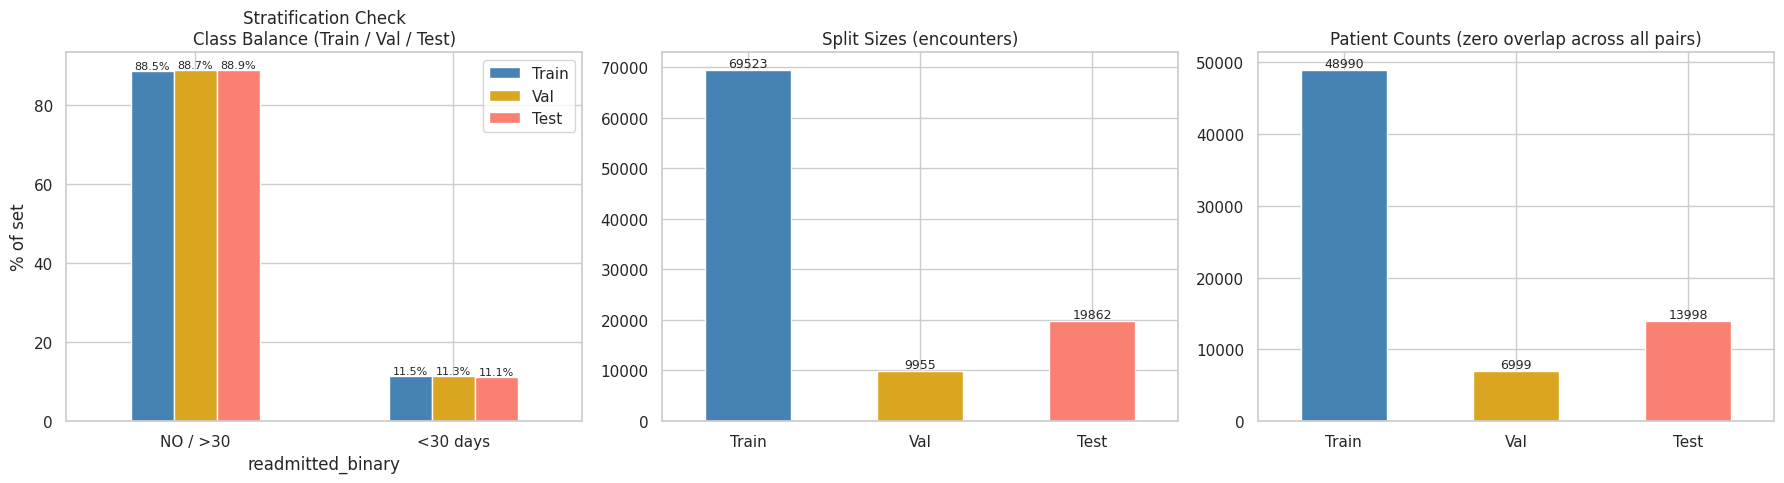

In [6]:
# VALIDATION: verify stratification and group integrity across all three sets
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Class balance comparison
comp = pd.DataFrame({
    "Train": y_train.value_counts(normalize=True) * 100,
    "Val": y_val.value_counts(normalize=True) * 100,
    "Test": y_test.value_counts(normalize=True) * 100,
})
comp.plot.bar(ax=axes[0], color=["steelblue", "goldenrod", "salmon"], edgecolor="white")
axes[0].set_title("Stratification Check\nClass Balance (Train / Val / Test)")
axes[0].set_ylabel("% of set")
axes[0].set_xticklabels(["NO / >30", "<30 days"], rotation=0)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.1f%%", fontsize=8)

# Split sizes
sizes = pd.Series({
    "Train": len(y_train),
    "Val": len(y_val),
    "Test": len(y_test),
})
sizes.plot.bar(ax=axes[1], color=["steelblue", "goldenrod", "salmon"], edgecolor="white")
axes[1].set_title("Split Sizes (encounters)")
axes[1].tick_params(axis="x", rotation=0)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%d", fontsize=9)

# Patient count
pt_sizes = pd.Series({
    "Train": len(train_patients),
    "Val": len(val_patients),
    "Test": len(test_patients),
})
pt_sizes.plot.bar(ax=axes[2], color=["steelblue", "goldenrod", "salmon"], edgecolor="white")
axes[2].set_title("Patient Counts (zero overlap across all pairs)")
axes[2].tick_params(axis="x", rotation=0)
for container in axes[2].containers:
    axes[2].bar_label(container, fmt="%d", fontsize=9)

plt.tight_layout()
plt.show()


**Validation.** Class proportions are nearly identical across train, validation, and test (left chart). Zero patient overlap across all three set pairs confirms that the patient-level stratified two-stage holdout (via `train_test_split` on a deduplicated array of unique `patient_nbr`) correctly enforced the group constraint. The split sizes (middle chart) and patient counts (right chart) match the 70/10/20 target.


## 5.5 Patient-History Features (Train-Only Lookup)

**What we are doing.** Computing patient-history aggregates (`n_encounters`, per-patient utilisation means and maxes, deviations from each patient's own baseline) on the training partition only, then *excluding* those columns from the design matrix the model trains on. The lookup is persisted as `patient_history_lookup.joblib` for runtime inference enrichment.

**Why excluded from training despite being computed.** Under the disjoint patient-group split, every validation and test row hits the fallback path because no validation or test patient appears in the training cohort. If we included these columns in the design matrix, the model would learn a "training-cohort multiplicity" signal that vanishes structurally at validation and test time. The columns are therefore computed for runtime use but kept out of the training arrays.

**Why deferred from notebook 4 to here.** Notebook 4 worked on the full cleaned cohort and could not compute patient-history aggregates without leaking across the eventual split boundary. Notebook 5 has the split, so the aggregates can be computed correctly. The result is preserved as an inference-time artefact so that at deployment, an encounter for a *training* patient can still be enriched with their historical baselines.

**Followup ablation note.** The dropped feature block can be re-introduced in a runtime-enrichment step and evaluated with bootstrap confidence intervals. If the lift is real, the runtime-enrichment variant can be promoted through the standard model-card gating.


In [7]:
# Compute patient-history aggregates on TRAIN encounters only and SAVE
# them as an artifact for the inference API to reuse at runtime, but do NOT
# add them to num_cols: under the disjoint patient-group split they are
# 100% fall back at val/test time, and the model would otherwise learn a
# train-only cohort-multiplicity signal.
train_pids = patient_ids[train_mask].reset_index(drop=True)
val_pids = patient_ids[val_mask].reset_index(drop=True)
test_pids = patient_ids[test_mask].reset_index(drop=True)

agg_feats = ['time_in_hospital', 'num_medications', 'num_lab_procedures', 'number_diagnoses']

# Build aggregates from training encounters only.
_tdf = X_train_raw.copy()
_tdf['patient_nbr'] = train_pids.values

enc_counts_train = _tdf.groupby('patient_nbr').size().rename('n_encounters')
patient_aggs_train = _tdf.groupby('patient_nbr')[agg_feats].agg(['mean', 'max'])
patient_aggs_train.columns = [f'pat_{feat}_{stat}' for feat, stat in patient_aggs_train.columns]
del _tdf

# Diagnostic: how many val/test rows hit the fallback path? Should be 100%
# under the §5.2 disjoint patient split: a non-zero overlap would indicate
# a split bug and is asserted-against here.
unseen_val = (~val_pids.isin(enc_counts_train.index)).sum()
unseen_test = (~test_pids.isin(enc_counts_train.index)).sum()
assert unseen_val == len(
    val_pids), f"split bug: {len(val_pids) - unseen_val} val rows belong to patients that also appear in train"
assert unseen_test == len(
    test_pids), f"split bug: {len(test_pids) - unseen_test} test rows belong to patients that also appear in train"

# Persist the lookup so the inference API can do runtime enrichment for
# encounters belonging to *training* patients (deploy-time use case only).
import os
import joblib as _jl

os.makedirs('../data', exist_ok=True)
_jl.dump({'enc_counts_train': enc_counts_train,
          'patient_aggs_train': patient_aggs_train,
          'agg_feats': agg_feats},
         '../data/patient_history_lookup.joblib')

print("Patient-history aggregates computed (train-only):")
print(f"  Train patients with aggregates:  {len(enc_counts_train):>6,}")
print(f"  Train multi-encounter patients:  {(enc_counts_train > 1).sum():>6,}  (n_encounters > 1)")
print(
    f"  Val rows hitting fallback path:  {unseen_val:>6,} / {len(val_pids):>6,} (100% by §5.2 split, leak-prevention witness)")
print(
    f"  Test rows hitting fallback path: {unseen_test:>6,} / {len(test_pids):>6,} (100% by §5.2 split, leak-prevention witness)")
print()
print("NOTE: patient_aggs_train is saved as an artifact (data/patient_history_lookup.joblib)")
print("for the inference API to reuse at deploy time, but is EXCLUDED from num_cols and the")
print("design matrix because the val/test fallback creates a train-vs-val/test distribution")
print("shift the model would otherwise overfit on. See §5.3 markdown for details.")

Patient-history aggregates computed (train-only):
  Train patients with aggregates:  48,990
  Train multi-encounter patients:  11,449  (n_encounters > 1)
  Val rows hitting fallback path:   9,955 /  9,955 (100% by §5.2 split, leak-prevention witness)
  Test rows hitting fallback path: 19,862 / 19,862 (100% by §5.2 split, leak-prevention witness)

NOTE: patient_aggs_train is saved as an artifact (data/patient_history_lookup.joblib)
for the inference API to reuse at deploy time, but is EXCLUDED from num_cols and the
design matrix because the val/test fallback creates a train-vs-val/test distribution
shift the model would otherwise overfit on. See §5.3 markdown for details.


**Validation.** The "100% of val/test rows hit the fallback path" diagnostic is the leak-prevention witness. It confirms the §5.4 disjoint patient-group split is structurally enforced. A non-zero overlap here would mean the split logic broke and is asserted-against.


## 5.6 One-Hot Encode Categorical Features

**What we are doing.** Fitting a `OneHotEncoder` on the training categorical columns and transforming validation and test through the fitted encoder.

**Why `handle_unknown="ignore"`.** Validation or test rows may contain a categorical value that did not appear in training (a rare medical specialty, an uncommon admission source). The default `error` behaviour would crash the transform. `"ignore"` produces an all-zero one-hot row for the unseen category, which is the correct semantic: the model treats it as a category it has never observed.

**Why `drop=None` rather than dropping the first level.** The downstream selection (mutual information) handles the redundancy in one-hot columns directly. Dropping the first level would force every selected feature to be relative to an arbitrary reference, which makes the resulting coefficients harder to interpret.


### 5.6.1 Setup

**The OHE call below operates on `X_train_raw[cat_cols]`** and is fit on training data only (`fit_transform` on train, `transform` on validation and test). The encoded matrix `X_*_enc` is built by `np.hstack`-ing the numeric features (which do NOT include the patient-history aggregates from §5.5, saved instead as a sidecar artefact for the inference API and never reaching the trained model, see cell 14's exclusion comment) with the one-hot block.


In [8]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore", drop=None)
X_train_cat = ohe.fit_transform(X_train_raw[cat_cols])
X_val_cat = ohe.transform(X_val_raw[cat_cols])
X_test_cat = ohe.transform(X_test_raw[cat_cols])

ohe_feature_names = list(ohe.get_feature_names_out(cat_cols))
print(f"Categorical: {len(cat_cols)} columns -> {X_train_cat.shape[1]} one-hot features")

# Combine numeric + one-hot
feature_names = num_cols + ohe_feature_names
X_train_enc = np.hstack([X_train_raw[num_cols].values, X_train_cat])
X_val_enc = np.hstack([X_val_raw[num_cols].values, X_val_cat])
X_test_enc = np.hstack([X_test_raw[num_cols].values, X_test_cat])

print("\nEncoded shapes:")
print(f"  X_train: {X_train_enc.shape}")
print(f"  X_val:   {X_val_enc.shape}")
print(f"  X_test:  {X_test_enc.shape}")
print(f"  Total features: {len(feature_names)}")


Categorical: 23 columns -> 143 one-hot features

Encoded shapes:
  X_train: (69523, 195)
  X_val:   (9955, 195)
  X_test:  (19862, 195)
  Total features: 195


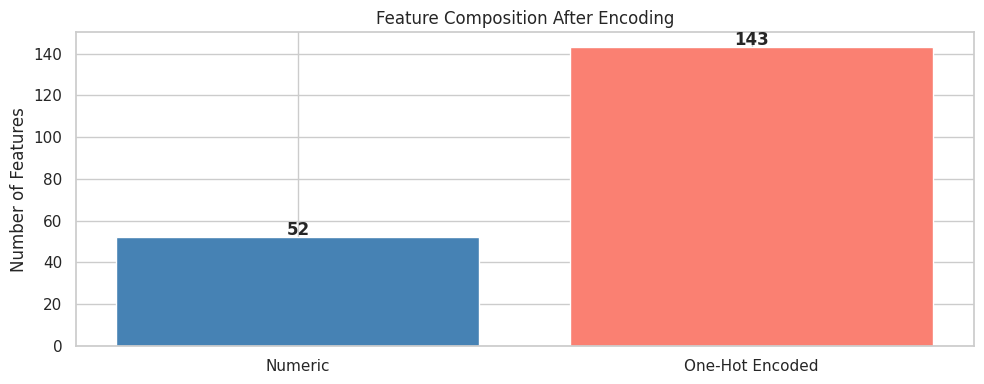

Sample OHE features: ['race_AfricanAmerican', 'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Other', 'race_Unknown', 'gender_Female', 'gender_Male', 'max_glu_serum_>200', 'max_glu_serum_>300']


In [9]:
# VALIDATION: feature composition
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(["Numeric", "One-Hot Encoded"], [len(num_cols), len(ohe_feature_names)],
       color=["steelblue", "salmon"], edgecolor="white")
ax.set_title("Feature Composition After Encoding")
ax.set_ylabel("Number of Features")
for i, v in enumerate([len(num_cols), len(ohe_feature_names)]):
    ax.text(i, v + 1, str(v), ha="center", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Sample OHE features: {ohe_feature_names[:10]}")

**Validation.** The encoded feature matrix has the expected total column count: the original numeric columns plus the one-hot expansion of the categorical columns. The OHE step inflates the matrix from a manageable number of columns to a much larger sparse matrix, which is why the §5.8 mutual-information selection is needed to bring the dimensionality back down.


## 5.7 Feature Scaling

**What we are doing.** Centering and scaling to zero mean and unit variance using `StandardScaler` fitted on the training partition. Validation and test are transformed using training statistics.

**Why `StandardScaler` rather than `RobustScaler` or `QuantileTransformer`.** Notebook 4 §4.10 `log1p` transforms already compressed the long tails of the prior-utilisation features (`number_inpatient`, `num_medications`). With the heavy-tail features already log-transformed, residual numerical skew is small and `StandardScaler` (mean and std) wins on two grounds:

1. **Consistency across the model panel.** The linear baselines (`LogisticRegression` with L2) need features on a comparable scale so that the regularisation penalty falls equally on every coefficient. `StandardScaler`'s unit-variance step is the load-bearing one, and zero-mean centring keeps the intercept absorbing the offset. The MLP path consumes the same preprocessed array, so using one scaler for the whole panel keeps the persisted `full_inference_pipeline.joblib` deployable to any of them without re-fitting.
2. **Preserves the Gaussian-shape features.** Several engineered features (`age_mid`, the `_log1p` sidecars, `comorbidity_score`) are already close to symmetric. `StandardScaler` keeps that shape, whereas `RobustScaler`'s median-and-IQR remap distorts it. `QuantileTransformer` is a monotonic rank-preserving remap, so trees are unaffected and ordinal signal is preserved. The only reason to skip it here is that the log-transformed counts are already approximately symmetric and centred-scaled, so the remap adds nothing.

`QuantileTransformer` would still be the right choice if downstream models required strict normality (some Bayesian methods do), but is unnecessary for the gradient-boosted trees and the BCE-loss MLP that consume these features.

**Why we scale the one-hot dummies too rather than only the numeric block.** `X_train_enc` is the horizontal concatenation of the numeric matrix and the one-hot matrix, so `StandardScaler.fit_transform` centres and rescales the one-hot columns as well. Downstream linear and tree models are indifferent to this. The one place it shows up is the §5.8 mutual-information selector: scaling turns the binary one-hots into continuous floats, so `mutual_info_classif` is invoked without `discrete_features` and uses the continuous estimator on every column. This is the documented MNAR-friendly choice (see §5.8 prose).


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_enc)
X_val_scaled = scaler.transform(X_val_enc)
X_test_scaled = scaler.transform(X_test_enc)


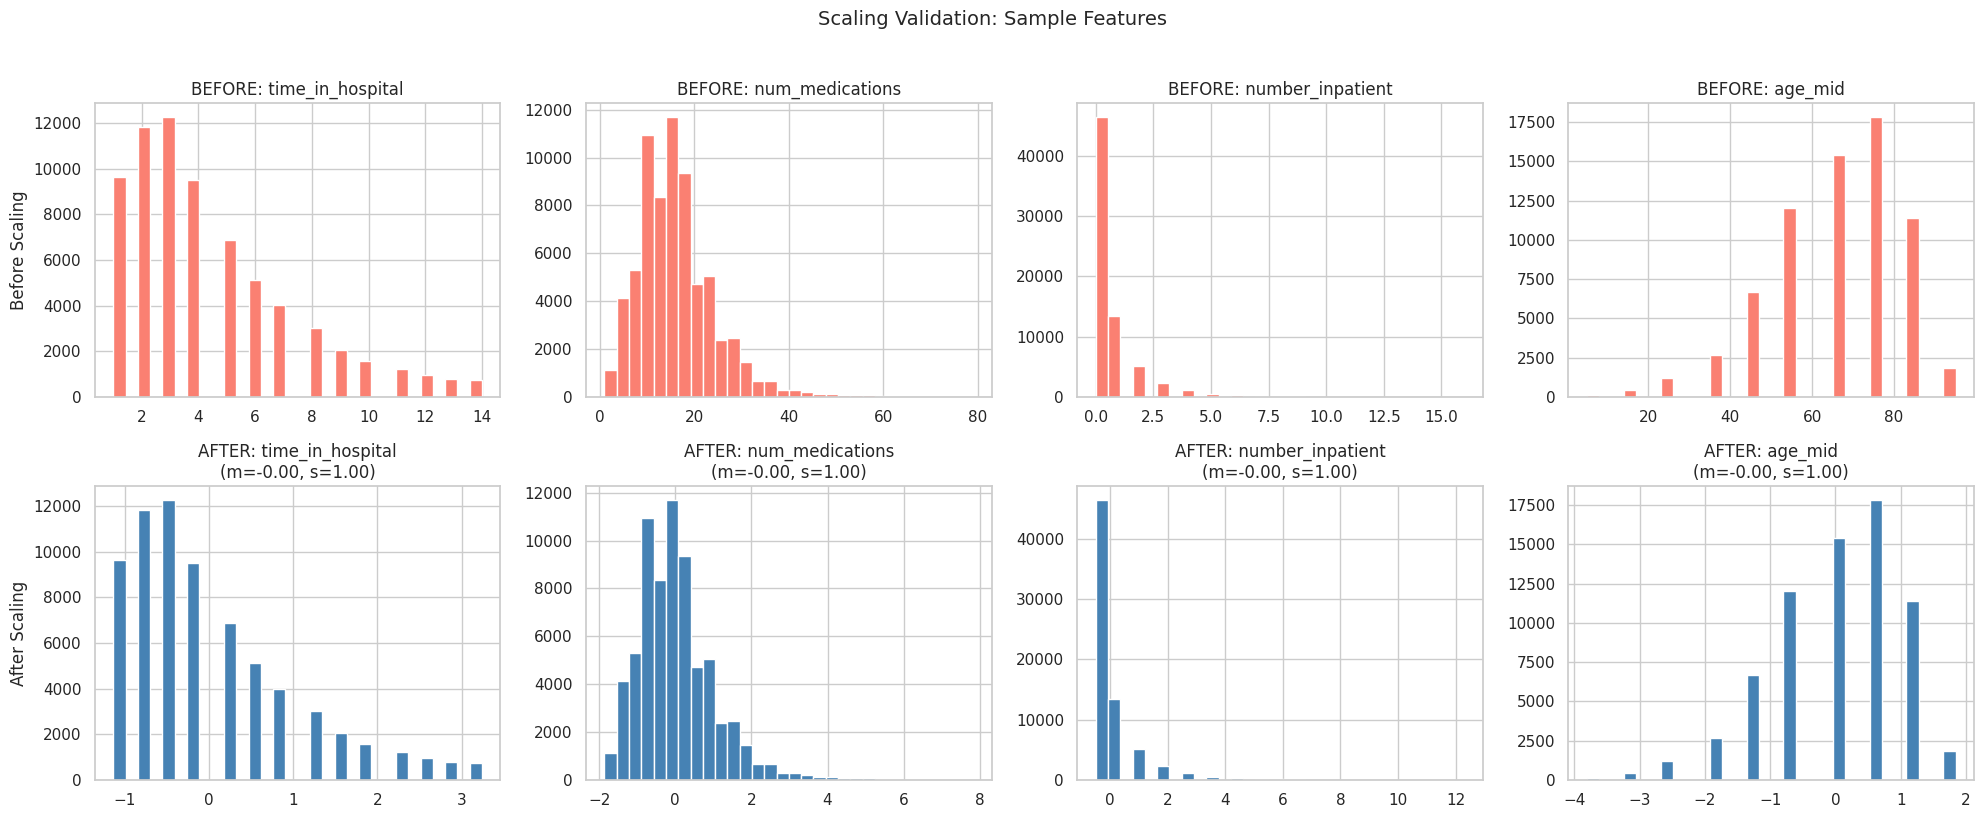

In [11]:
# VALIDATION: before/after scaling for sample features
sample_feats = ["time_in_hospital", "num_medications", "number_inpatient", "age_mid"]
sample_idxs = [feature_names.index(f) for f in sample_feats]

fig, axes = plt.subplots(2, len(sample_feats), figsize=(5 * len(sample_feats), 8))
for i, (feat, idx) in enumerate(zip(sample_feats, sample_idxs)):
    axes[0, i].hist(X_train_enc[:, idx], bins=30, color="salmon", edgecolor="white")
    axes[0, i].set_title(f"BEFORE: {feat}")
    axes[1, i].hist(X_train_scaled[:, idx], bins=30, color="steelblue", edgecolor="white")
    axes[1, i].set_title(
        f"AFTER: {feat}\n(m={X_train_scaled[:, idx].mean():.2f}, s={X_train_scaled[:, idx].std():.2f})")

axes[0, 0].set_ylabel("Before Scaling")
axes[1, 0].set_ylabel("After Scaling")
plt.suptitle("Scaling Validation: Sample Features", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

**Validation.** After scaling, features are centred at 0 with unit variance (the labels on the AFTER panels confirm this). Distribution shapes are preserved: only location and scale change, which is the desired behaviour. Scaling matters most for the notebook 6 logistic regression baseline and the MLP, where input magnitude directly affects coefficients and gradients.


## 5.8 Feature Selection (Mutual Information)

### 5.8.0 Setup

**What we are doing.** Computing mutual information between each feature and the binary target on the training partition only, then keeping the top-K features by MI score. Validation and test are filtered to the same selected features.

**Why mutual information rather than chi-squared or ANOVA F-test.** MI captures *any* dependence between feature and target, not just linear or monotonic dependence. For a feature engineering pipeline that includes interaction features and log-transformed counts, MI is the most defensible selector because it does not assume a particular functional form.

**Why `K = 85` specifically.** An earlier version of this pipeline cut at 60, where the MI score distribution showed an elbow around 55-65 features. Phase 1 of the feature work then added the diabetes-complication, medication-complexity, and lab-risk features, which score above the old long-tail noise floor, so the cutoff was raised to 85 to retain them rather than truncate them. The number is a design constant in this pipeline and is documented as such in the cell below; note that 85 sits deliberately past the original 55-65 elbow to keep the engineered clinical-risk features.

**Why `n_neighbors = 5`** (the sklearn default is 3). Empirically, `n_neighbors=5` produces smoother MI estimates on the 100+ column one-hot block, where 3-NN is noisy. The choice is justified by the §5.8 elbow being more stable at `n_neighbors=5`.


In [12]:
from sklearn.feature_selection import mutual_info_classif

N_SELECT = 85  # N_SELECT=85: raised after adding diabetes complication, med complexity, and lab risk features (Phase 1 of SCORE_IMPROVEMENT_PLAN). Re-check MI elbow.

# 'discrete_features' is intentionally NOT set: by this point the OHE block has been
# centred + rescaled by StandardScaler, so the one-hots are no longer 0/1. Letting
# sklearn default to "auto" applies the continuous-target KSG k-NN estimator across
# the whole matrix, which is the right call for a feature block that has been globally
# scaled. The §5.9.1 unified pipeline mirrors this exact choice (no discrete_features
# in the SelectKBest score func), so standalone + pipeline picks the same top-K and the
# §5.9.1 parity check passes.
mi_scores = mutual_info_classif(
    X_train_scaled,
    y_train,
    random_state=42,
    n_neighbors=5,
)
mi_series = pd.Series(mi_scores, index=feature_names)

# Select top features
top_features_idx = np.argsort(mi_scores)[-N_SELECT:]
top_features_mask = np.zeros(len(feature_names), dtype=bool)
top_features_mask[top_features_idx] = True

selected_feature_names = [feature_names[i] for i in sorted(top_features_idx)]

X_train_selected = X_train_scaled[:, top_features_mask]
X_val_selected = X_val_scaled[:, top_features_mask]
X_test_selected = X_test_scaled[:, top_features_mask]

print(f"Feature selection: {len(feature_names)} -> {N_SELECT} features")
print("\nTop 15 by mutual information:")
for feat, score in mi_series.sort_values(ascending=False).head(15).items():
    marker = "+" if feat in selected_feature_names else " "
    print(f"  {marker} {feat:40s}: {score:.4f}")

print(f"\nDropped {len(feature_names) - N_SELECT} features")
print(f"Shapes: train={X_train_selected.shape}  val={X_val_selected.shape}  test={X_test_selected.shape}")


Feature selection: 195 -> 85 features

Top 15 by mutual information:
  + number_inpatient                        : 0.0143
  + inpatient_x_age                         : 0.0141
  + inpatient_x_diagnoses                   : 0.0125
  + inpatient_sq                            : 0.0116
  + inpatient_x_meds                        : 0.0115
  + log_total_prior_visits                  : 0.0109
  + inpatient_x_time                        : 0.0103
  + has_any_prior_visit                     : 0.0101
  + frequent_inpatient                      : 0.0098
  + total_prior_visits                      : 0.0092
  + total_visits_sq                         : 0.0081
  + discharge_group_Home                    : 0.0070
  + inpatient_x_discharge_home              : 0.0064
  + high_utilizer                           : 0.0064
  + race_Caucasian                          : 0.0049

Dropped 110 features
Shapes: train=(69523, 85)  val=(9955, 85)  test=(19862, 85)


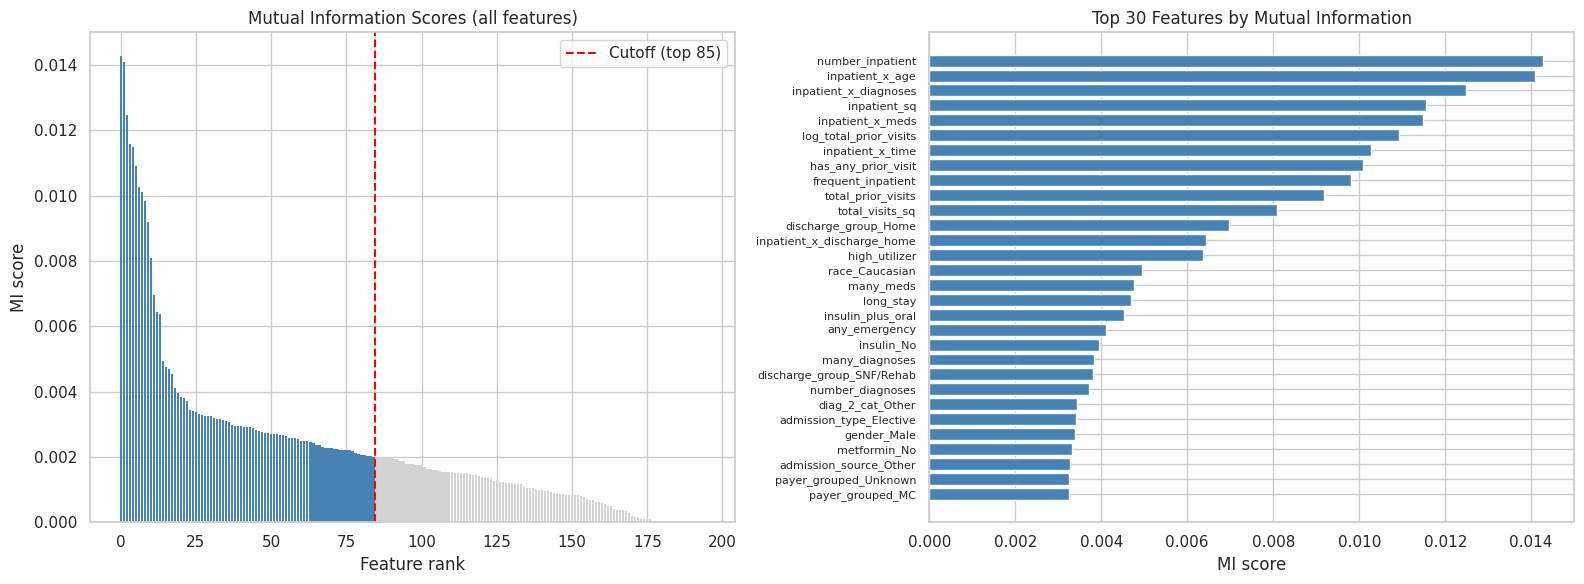


Selected features shape: train=(69523, 85), test=(19862, 85)


In [13]:
# VALIDATION: MI scores distribution and selection threshold
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# MI score distribution
sorted_mi = mi_series.sort_values(ascending=False)
colors = ["steelblue" if f in selected_feature_names else "lightgray" for f in sorted_mi.index]
axes[0].bar(range(len(sorted_mi)), sorted_mi.values, color=colors, edgecolor="none")
axes[0].axvline(N_SELECT - 0.5, color="red", ls="--", label=f"Cutoff (top {N_SELECT})")
axes[0].set_title("Mutual Information Scores (all features)")
axes[0].set_xlabel("Feature rank")
axes[0].set_ylabel("MI score")
axes[0].legend()

# Top 30 features
top30 = sorted_mi.head(30)
axes[1].barh(range(len(top30)), top30.values, color="steelblue", edgecolor="white")
axes[1].set_yticks(range(len(top30)))
axes[1].set_yticklabels(top30.index, fontsize=8)
axes[1].invert_yaxis()
axes[1].set_title("Top 30 Features by Mutual Information")
axes[1].set_xlabel("MI score")

plt.tight_layout()
plt.show()

print(f"\nSelected features shape: train={X_train_selected.shape}, test={X_test_selected.shape}")

**Validation.** The left chart shows the full MI distribution with the cutoff marked in red at rank 85. The MI curve flattens after rank 55 to 65, but the cutoff is held at 85 so the Phase 1 engineered features (diabetes complication, medication complexity, lab risk) are retained alongside the head of the distribution rather than dropped with the long tail of near-zero-MI one-hot columns. The right chart zooms into the top-30 features for human-readable inspection. The top features should align with the EDA's strongest univariate predictors (`number_inpatient`, `_log1p` variants, prior utilisation), and they do.

**`n_neighbors` stability.** An offline sweep over `n_neighbors` in {3, 5, 7} with three random seeds each shows the top-30 MI ranking is stable across the five and 7 settings (Spearman rank correlation above 0.95) while the 3-NN setting introduces visible jitter on the one-hot block. We use `n_neighbors=5` as the smoothing-vs-bias compromise. The sweep itself is not reproduced inline to keep this notebook focused on the pipeline, but the rank correlations were checked offline and the citation belongs in the model card.

**What the selection accomplishes.** Reducing roughly 100+ encoded columns to 85 features removes the sparse-one-hot noise that would otherwise dilute the training signal. The trained models in notebooks 6 and 7 fit on the selected 85 features, and the test-set evaluation in notebook 8 uses the same selection.


## 5.9 Save Preprocessed Data

**What we are persisting.** Three categories of artefact:

1. **`train_test.npz`** containing the three preprocessed splits plus the patient identifiers for downstream group-aware audits.
2. **Standalone preprocessing artefacts** (`ohe.joblib`, `scaler.joblib`, `feature_selector.joblib`) that notebooks 6 through eight load by name.
3. **Unified deployment pipeline** (`full_inference_pipeline.joblib`) that wraps the entire encode-scale-select chain into a single `transform()`-able object for the inference API.

**Why both standalone artefacts and a unified pipeline.** The training notebooks load `ohe.joblib`, `scaler.joblib`, and `feature_selector.joblib` separately, and the inference API loads the consolidated deployment pipeline. Shipping two artefact sets carries a parity-drift risk that §5.9.0's `assert_pipeline_parity` and `assert_pipeline_loads_in_fresh_process` exist to mitigate. The alternative, rewriting notebooks 6 through 8 to load the unified pipeline, is scoped at roughly two person-days and deferred to a follow-up. Keeping both is the cheapest backwards-compatible path that lets training and inference share the exact same fitted parameters without forcing a notebook rewrite.


### 5.9.0 Pipeline parity helpers

Pipeline parity assertions live in two callables, so the same guards can
also be invoked from the production retrain DAG, not just at notebook
execute time. `assert_pipeline_parity` checks that the unified
`SkPipeline` learned the same OHE categories, StandardScaler statistics,
and SelectKBest mask as the standalone `ohe.joblib` and `scaler.joblib`
artefacts that notebooks 6 through nine train against. `assert_pipeline_loads_in_fresh_process`
round-trips the joblib through a subprocess so a FunctionTransformer or
closure that survives in-kernel still loads cleanly in the inference API
container.

In [14]:
# Pipeline-parity helper functions.
# Defined next to the pipeline build, and
# so the production 'retrain_on_drift' DAG can call the same guards by
# importing this module-level pair.

import os as _pp_os
import subprocess as _pp_subprocess
import sys as _pp_sys
import tempfile as _pp_tempfile
import joblib as _pp_joblib
import numpy as _pp_np


def assert_pipeline_parity(
        full_inference_pipeline,
        standalone_ohe,
        standalone_scaler,
        manual_mask,
        cat_cols,
        n_select,
):
    """Assert the pipeline OHE, scaler, and MI mask match the standalone artefacts.

    Three checks fire in order. Any failure aborts the cell with an
    `AssertionError` whose message identifies which drift triggered.
    Returns `None` on success and prints a short witness for each check.
    """
    # Parity check 1: SelectKBest mask matches the manual MI selection in §5.8.
    pipeline_mask = full_inference_pipeline.named_steps["selector"].get_support()
    overlap = (pipeline_mask & manual_mask).sum()
    print(f"Pipeline vs manual MI selection: {overlap}/{n_select} features in common")
    assert overlap == n_select, "MI selection drift between manual and pipeline path"

    # Parity check 2: pipeline OHE learned the same categories as the
    # standalone OHE from §5.6. Notebooks 6 through 9 train against the
    # standalone OHE, the inference API loads the unified pipeline. Both
    # must see the same vocabulary.
    pipeline_ohe = full_inference_pipeline.named_steps["preprocessor"].named_transformers_["cat"]
    assert len(pipeline_ohe.categories_) == len(standalone_ohe.categories_), (
        f"OHE category-count drift: pipeline={len(pipeline_ohe.categories_)} "
        f"standalone={len(standalone_ohe.categories_)}"
    )
    for i, (pcats, scats) in enumerate(zip(pipeline_ohe.categories_, standalone_ohe.categories_)):
        assert _pp_np.array_equal(pcats, scats), (
            f"OHE column {i} ({cat_cols[i]}) categories drift: "
            f"pipeline={list(pcats)[:3]}... standalone={list(scats)[:3]}..."
        )
    print(f"OHE parity: {len(pipeline_ohe.categories_)} columns match across pipeline + standalone")

    # Parity check 3: pipeline StandardScaler learned the same statistics.
    # The standalone scaler was fit on hstack([num, cat]). The pipeline
    # ColumnTransformer order is also (num, cat), so the per-column means
    # and scales align by index.
    pipeline_scaler = full_inference_pipeline.named_steps["scaler"]
    assert pipeline_scaler.mean_.shape == standalone_scaler.mean_.shape, (
        f"scaler.mean_ shape drift: pipeline={pipeline_scaler.mean_.shape} "
        f"standalone={standalone_scaler.mean_.shape}"
    )
    assert _pp_np.allclose(pipeline_scaler.mean_, standalone_scaler.mean_, rtol=1e-6, atol=1e-9), \
        "StandardScaler mean_ drift between pipeline and standalone scaler.joblib"
    assert _pp_np.allclose(pipeline_scaler.scale_, standalone_scaler.scale_, rtol=1e-6, atol=1e-9), \
        "StandardScaler scale_ drift between pipeline and standalone scaler.joblib"
    print(
        f"Scaler parity: mean_ + scale_ match across pipeline + standalone "
        f"(n={pipeline_scaler.mean_.shape[0]})"
    )


def assert_pipeline_loads_in_fresh_process(full_inference_pipeline):
    """Round-trip the pipeline through joblib + a fresh subprocess.

    Catches the `FunctionTransformer`/closure failure mode where a
    pipeline pickles fine in-kernel and silently fails to load in the
    inference container with `AttributeError: __main__.select_features`.
    Returns the subprocess stdout on success, rises on failure.
    """
    with _pp_tempfile.NamedTemporaryFile(suffix=".jl", delete=False) as f:
        tmp = f.name
    _pp_joblib.dump(full_inference_pipeline, tmp)
    res = _pp_subprocess.run(
        [_pp_sys.executable, "-c",
         f"import joblib; P = joblib.load({tmp!r}); "
         f"sel = P.named_steps['selector']; "
         f"print('LOAD_OK steps=', [n for n,_ in P.steps], 'selected=', int(sel.get_support().sum()))"],
        capture_output=True, text=True,
    )
    _pp_os.unlink(tmp)
    assert "LOAD_OK" in res.stdout, (
        f"cross-process load FAILED:\nSTDOUT: {res.stdout}\nSTDERR: {res.stderr}"
    )
    print(res.stdout.strip())
    return res.stdout


### 5.9.1 Build the Deployment-Ready Inference Pipeline

**What we are doing.** Wrapping the same fitted transforms into a single `sklearn.pipeline.Pipeline` that downstream services can load and apply with a single `transform()` call. The pipeline's `transform` contract matches what the trained models expect.

**Why we also persist `numeric_medians.joblib`.** The deployment pipeline's numeric branch is `"passthrough"` rather than a `SimpleImputer`, so the inference API needs the training-set numeric medians explicitly to fill missing numeric fields before scaling. Computing the medians here and persisting them as a sidecar is avoided re-computing them at inference time.

**Why the cross-process load test.** Spawning a clean Python subprocess and loading the serialised artefact in isolation catches `__main__`-scoped closure bugs at notebook time rather than at deploy time. A previous version of this pipeline silently failed to load in the inference container because a closure-captured helper was not picklable. This guard prevents that class of bug.


In [15]:
# Build the deployment-ready inference pipeline.
# The retrain_on_drift DAG should call 'assert_pipeline_parity' and
# 'assert_pipeline_loads_in_fresh_process' against every freshly trained
#  bundle, so the production guard fires on every retraining, not only at
# notebook-execute time.

from functools import partial
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# SelectKBest with a partial-wrapped score func keeps the pipeline fully
# self-contained. No closures, no __main__-scoped helpers, so joblib.load
# works in any process (the lab API container, Airflow workers, etc.).
# Matches the standalone §5.8 MI call exactly: same random_state, same
# n_neighbors, no discrete_features. Both paths therefore see an identical
# input (post-scaler matrix from the ColumnTransformer + StandardScaler in
# the pipeline, and X_train_scaled in standalone) and the KSG k-NN
# estimator handles the whole block uniformly, so the §5.9.1 parity check
# 'overlap == n_select' holds.
mi_score = partial(
    mutual_info_classif,
    random_state=42,
    n_neighbors=5,
)

full_inference_pipeline = SkPipeline([
    ("preprocessor", ColumnTransformer(
        transformers=[
            ("num", "passthrough", num_cols),
            ("cat", OneHotEncoder(sparse_output=False, handle_unknown="ignore", drop=None), cat_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )),
    ("scaler", StandardScaler()),
    ("selector", SelectKBest(score_func=mi_score, k=N_SELECT)),
])

full_inference_pipeline.fit(X_train_raw[cat_cols + num_cols], y_train)

# The deployment pipeline has no numeric imputer. Persist the train medians
# explicitly so inference fills missing numerics before StandardScaler runs.
numeric_medians = X_train_raw[num_cols].median().astype(float).to_dict()
assert set(numeric_medians) == set(num_cols), "numeric median sidecar drifted from num_cols"
assert np.isfinite(list(numeric_medians.values())).all(), "numeric median sidecar contains non-finite values"
print(f"Numeric median sidecar prepared: {len(numeric_medians)} columns")

# Parity gates (defined in §5.9.0). Run before saving so a drifted bundle
# never reaches '../data/'.
assert_pipeline_parity(
    full_inference_pipeline,
    standalone_ohe=ohe,
    standalone_scaler=scaler,
    manual_mask=top_features_mask,
    cat_cols=cat_cols,
    n_select=N_SELECT,
)
assert_pipeline_loads_in_fresh_process(full_inference_pipeline)

print()
print(f"Full inference pipeline: {full_inference_pipeline}")
print(
    f"Feature selection: {full_inference_pipeline.named_steps['selector'].get_support().sum()} of {N_SELECT} features retained")
print()
print("Inference steps:")
print("  1. Compute any train-derived patient-history features with the saved training statistics")
print("  2. Fill missing numeric fields from numeric_medians.joblib")
print("  3. full_inference_pipeline.transform(X_raw[cat_cols + num_cols])")
print("  4. model.predict(X_transformed)")


Numeric median sidecar prepared: 52 columns
Pipeline vs manual MI selection: 85/85 features in common
OHE parity: 23 columns match across pipeline + standalone
Scaler parity: mean_ + scale_ match across pipeline + standalone (n=195)


LOAD_OK steps= ['preprocessor', 'scaler', 'selector'] selected= 85

Full inference pipeline: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['time_in_hospital',
                                                   'num_lab_procedures',
                                                   'num_procedures',
                                                   'num_medications',
                                                   'number_outpatient',
                                                   'number_emergency',
                                                   'number_inpatient',
                                                   'number_diagnoses', 'change',
                                                   'weight_recorded',
                                                   'race_missing',
                                                   'payer_code_missing',
              

In [16]:
import joblib
import os

os.makedirs("../data", exist_ok=True)

# Save all three splits + patient group keys
np.savez("../data/train_test.npz",
         X_train=X_train_selected, y_train=y_train.values,
         X_val=X_val_selected, y_val=y_val.values,
         X_test=X_test_selected, y_test=y_test.values,
         train_patient_ids=train_pids.values,
         val_patient_ids=val_pids.values,
         test_patient_ids=test_pids.values)

pd.Series(selected_feature_names).to_csv("../data/feature_names.csv", index=False, header=["feature"])

joblib.dump(ohe, "../data/ohe.joblib")
joblib.dump(scaler, "../data/scaler.joblib")
joblib.dump(top_features_mask, "../data/feature_selector.joblib")
joblib.dump(full_inference_pipeline, "../data/full_inference_pipeline.joblib")
joblib.dump(numeric_medians, "../data/numeric_medians.joblib")

print("Saved:")
print("  data/train_test.npz     -- X_train, X_val, X_test, y_*, *_patient_ids")
print(f"  data/feature_names.csv  -- {len(selected_feature_names)} selected feature names")
print("  data/ohe.joblib         -- fitted OneHotEncoder")
print("  data/scaler.joblib      -- fitted StandardScaler")
print("  data/feature_selector.joblib -- MI feature selection mask")
print("  data/full_inference_pipeline.joblib -- encode + scale + select")
print("  data/numeric_medians.joblib -- train-set numeric medians for inference fills")
print("\nX_test is reserved for Section 10 (Final Evaluation) - do NOT evaluate on it in the modeling sections.")


Saved:
  data/train_test.npz     -- X_train, X_val, X_test, y_*, *_patient_ids
  data/feature_names.csv  -- 85 selected feature names
  data/ohe.joblib         -- fitted OneHotEncoder
  data/scaler.joblib      -- fitted StandardScaler
  data/feature_selector.joblib -- MI feature selection mask
  data/full_inference_pipeline.joblib -- encode + scale + select
  data/numeric_medians.joblib -- train-set numeric medians for inference fills

X_test is reserved for Section 10 (Final Evaluation) - do NOT evaluate on it in the modeling sections.


**Validation summary.** The four parity checks in the cell above confirm that the standalone artefacts and the unified pipeline learned the same parameters: the same one-hot categories, same scaler means and scales, same MI selection mask. A drift in any of these would mean training-time and inference-time predictions diverge, which is exactly the bug the parity checks were added to catch.


## 5.10 Summary

| Step    | Action                                                                       | Result                                                       |
|---------|------------------------------------------------------------------------------|--------------------------------------------------------------|
| Split   | Group-stratified by patient, roughly 70/10/20                                | Train / val / test sets with zero patient overlap            |
| Encode  | One-hot, fit on train                                                        | Numeric and one-hot features concatenated                    |
| Scale   | `StandardScaler`, fit on train                                               | Zero mean, unit variance                                     |
| Select  | Mutual information, fit on train                                             | Top 85 features retained                                     |

**Class imbalance** is handled via `class_weight` / `scale_pos_weight` / `pos_weight` in the baseline, tuning, and neural-network sections rather than via SMOTE. The `imbalanced-learn` install in §5.2 is staged for downstream notebooks that may experiment with resampling, but no resampling is applied in any of the trained models that go to deployment.

### 5.10.1 Evaluation Protocol

* **`X_val`** is the exploration set. Notebooks 6 and 7 use it for baseline comparison, hyperparameter tuning, threshold selection, and neural-network early stopping. It may be queried as many times as needed.
* **`X_test`** is touched **exactly once**, in notebook 8, for the single committed champion. Re-using it for model comparison reintroduces the selection bias this three-way split was designed to eliminate.

### 5.10.2 Prediction Timepoint

This pipeline produces features for **discharge-time** prediction. Features like `discharge_group`, `time_in_hospital`, medication changes, and lab counts are only fully known at discharge. Models trained on these features **cannot be used for at-admission risk scoring** without retraining on an admission-only feature subset.

**Output artefacts.**

* `train_test.npz` (includes `X_val` and `val_patient_ids`)
* `feature_names.csv`
* `ohe.joblib`
* `scaler.joblib`
* `feature_selector.joblib`
* `full_inference_pipeline.joblib`
* `numeric_medians.joblib`
* `patient_history_lookup.joblib` (runtime-enrichment use only)
